In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

In [2]:
dataset_path = "city_temperature.csv"

df = pd.read_csv(

    dataset_path

)

print("\n")

print("="*70)

print("Dataset Loaded Successfully")

print("="*70)



Dataset Loaded Successfully


In [3]:
print("\n")

print("="*70)

print("First Five Records")

print("="*70)

display(

    df.head()

)




First Five Records


,Region,Country,State,City,Month,Day,Year,AvgTemperature
0,Africa,Algeria,NaN,Algiers,1,1,1995,64.2
1,Africa,Algeria,NaN,Algiers,1,2,1995,49.4
2,Africa,Algeria,NaN,Algiers,1,3,1995,48.8
3,Africa,Algeria,NaN,Algiers,1,4,1995,46.4
4,Africa,Algeria,NaN,Algiers,1,5,1995,47.9


In [4]:
print("\n")

print("="*70)

print("Dataset Shape")

print("="*70)

print(

    "Rows :", df.shape[0]

)

print(

    "Columns :", df.shape[1]

)




Dataset Shape
Rows : 2906327
Columns : 8


In [5]:
print("\n")

print("="*70)

print("Dataset Information")

print("="*70)

df.info()



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 2906327 entries, 0 to 2906326
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Region          str    
 1   Country         str    
 2   State           str    
 3   City            str    
 4   Month           int64  
 5   Day             int64  
 6   Year            int64  
 7   AvgTemperature  float64
dtypes: float64(1), int64(3), str(4)
memory usage: 177.4 MB


In [6]:
print("\n")

print("="*70)

print("Data Types")

print("="*70)

display(

    pd.DataFrame(

        df.dtypes,

        columns=["Data Type"]

    )

)




Data Types


,Data Type
Region,str
Country,str
State,str
City,str
Month,int64
Day,int64
Year,int64
AvgTemperature,float64


In [7]:
missing_values = df.isnull().sum()

print("\n")

print("="*70)

print("Missing Values")

print("="*70)

display(

    missing_values[

        missing_values > 0

    ]

)



Missing Values


State    1450990
dtype: int64

In [8]:
duplicates = df.duplicated().sum()

print("\n")

print("="*70)

print("Duplicate Records")

print("="*70)

print(

    duplicates

)



Duplicate Records
20715


In [9]:
print("\n")

print("="*70)

print("Statistical Summary")

print("="*70)

display(

    df.describe()

)



Statistical Summary


,Month,Day,Year,AvgTemperature
count,2.906327e+06,2.906327e+06,2.906327e+06,2.906327e+06
mean,6.469163e+00,1.571682e+01,2.006624e+03,5.600492e+01
std,3.456489e+00,8.800534e+00,2.338226e+01,3.212359e+01
min,1.000000e+00,0.000000e+00,2.000000e+02,-9.900000e+01
25%,3.000000e+00,8.000000e+00,2.001000e+03,4.580000e+01
50%,6.000000e+00,1.600000e+01,2.007000e+03,6.250000e+01
75%,9.000000e+00,2.300000e+01,2.013000e+03,7.550000e+01
max,1.200000e+01,3.100000e+01,2.020000e+03,1.100000e+02


In [10]:
print("\n")

print("="*70)

print("Number of Cities")

print("="*70)

print(

    df["City"].nunique()

)

print("\n")

print("Sample Cities")

print(

    df["City"].unique()[:20]

)




Number of Cities
321


Sample Cities
<StringArray>
[     'Algiers',    'Bujumbura',      'Cotonou',       'Bangui',
  'Brazzaville',        'Cairo',  'Addis Ababa',   'Libreville',
       'Banjul',      'Conakry',       'Bissau',      'Abidjan',
      'Nairobi',        'Rabat', 'Antananarivo',   'Nouakchott',
     'Lilongwe',       'Maputo',     'Windhoek',       'Niamey']
Length: 20, dtype: str


In [11]:
city_name = df["City"].value_counts().index[0]

city_df = df[

    df["City"] == city_name

].copy()

print("\n")

print("="*70)

print("Selected City")

print("="*70)

print(

    city_name

)

print(

    "Records :", len(city_df)

)




Selected City
Washington
Records : 18530


In [12]:
city_df = city_df.dropna(

    subset=["AvgTemperature"]

)


In [13]:
print("\n")

print("="*70)

print("Temperature Statistics")

print("="*70)

display(

    city_df["AvgTemperature"].describe()

)



Temperature Statistics


count    18530.000000
mean        58.272035
std         18.048242
min        -99.000000
25%         44.500000
50%         59.000000
75%         74.000000
max         92.800000
Name: AvgTemperature, dtype: float64

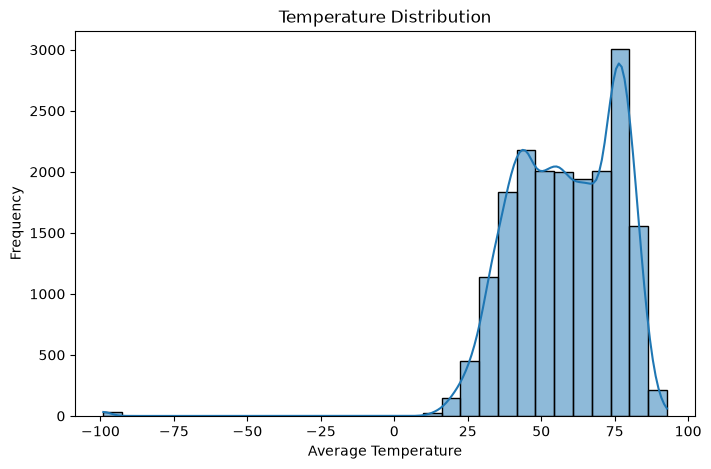

In [14]:
plt.figure(

    figsize=(8,5)

)

sns.histplot(

    city_df["AvgTemperature"],

    bins=30,

    kde=True

)

plt.title(

    "Temperature Distribution"

)

plt.xlabel(

    "Average Temperature"

)

plt.ylabel(

    "Frequency"

)

plt.show()


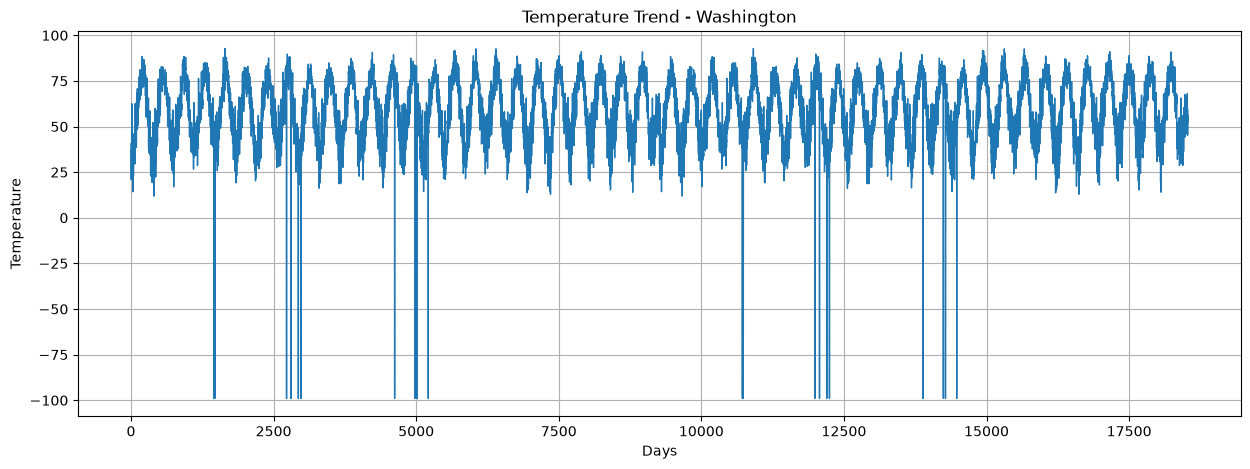

In [15]:
plt.figure(

    figsize=(15,5)

)

plt.plot(

    city_df["AvgTemperature"].values,

    linewidth=1

)

plt.title(

    f"Temperature Trend - {city_name}"

)

plt.xlabel(

    "Days"

)

plt.ylabel(

    "Temperature"

)

plt.grid()

plt.show()


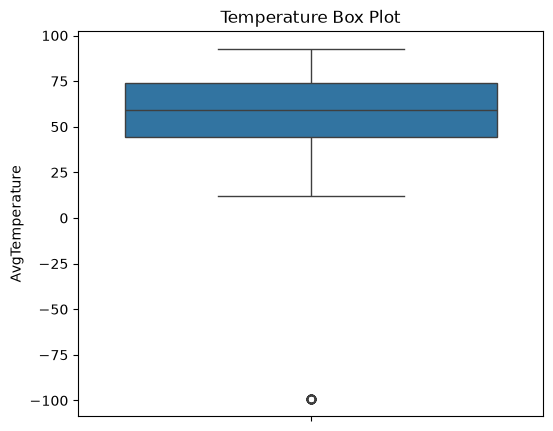

In [16]:
plt.figure(

    figsize=(6,5)

)

sns.boxplot(

    y=city_df["AvgTemperature"]

)

plt.title(

    "Temperature Box Plot"

)

plt.show()


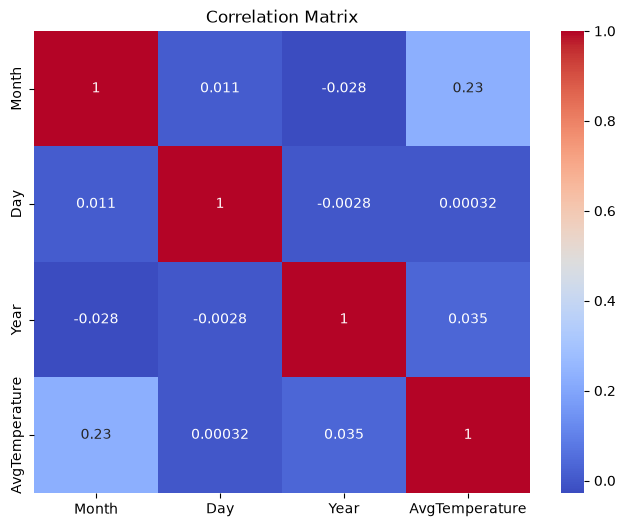

In [17]:
numeric_df = city_df.select_dtypes(

    include=np.number

)

plt.figure(

    figsize=(8,6)

)

sns.heatmap(

    numeric_df.corr(),

    annot=True,

    cmap="coolwarm"

)

plt.title(

    "Correlation Matrix"

)

plt.show()


In [18]:
summary = pd.DataFrame({

    "Parameter":[

        "Dataset",

        "Selected City",

        "Total Records",

        "Temperature Column",

        "Problem Type",

        "Model"

    ],

    "Value":[

        "City Temperature",

        city_name,

        len(city_df),

        "AvgTemperature",

        "Sequence Prediction",

        "Simple RNN"

    ]

})

print("\n")

print("="*70)

print("Dataset Summary")

print("="*70)

display(

    summary

)




Dataset Summary


,Parameter,Value
0,Dataset,City Temperature
1,Selected City,Washington
2,Total Records,18530
3,Temperature Column,AvgTemperature
4,Problem Type,Sequence Prediction
5,Model,Simple RNN


In [19]:
print(df.columns.tolist())

['Region', 'Country', 'State', 'City', 'Month', 'Day', 'Year', 'AvgTemperature']


In [20]:
import numpy as np

import pandas as pd

import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

In [21]:
city_df["Date"] = pd.to_datetime(

    city_df[["Year","Month","Day"]],

    errors="coerce"

)

city_df = city_df.dropna(

    subset=["Date"]

)

city_df = city_df.sort_values(

    "Date"

).reset_index(

    drop=True

)

print("\n")

print("="*70)

print("Date Column Created Successfully")

print("="*70)

display(

    city_df.head()

)




Date Column Created Successfully


,Region,Country,State,City,Month,Day,Year,AvgTemperature,Date
0,North America,US,District of Columbia,Washington,1,1,1995,40.6,1995-01-01
1,North America,US,District of Columbia,Washington,1,1,1995,40.6,1995-01-01
2,North America,US,District of Columbia,Washington,1,2,1995,39.8,1995-01-02
3,North America,US,District of Columbia,Washington,1,2,1995,39.8,1995-01-02
4,North America,US,District of Columbia,Washington,1,3,1995,29.3,1995-01-03


In [22]:
temperature_df = city_df[[

    "Date",

    "AvgTemperature"

]].copy()

In [23]:
temperature_df = temperature_df[

    temperature_df["AvgTemperature"] > -50

]

temperature_df = temperature_df.reset_index(

    drop=True

)

print("\n")

print("="*70)

print("Dataset after Cleaning")

print("="*70)

print(

    "Total Records :",

    len(

        temperature_df

    )

)




Dataset after Cleaning
Total Records : 18498


In [24]:
scaler = MinMaxScaler()

temperature_df["ScaledTemperature"] = scaler.fit_transform(

    temperature_df[["AvgTemperature"]]

)

print("\n")

print("="*70)

print("Normalization Completed")

print("="*70)

display(

    temperature_df.head()

)



Normalization Completed


,Date,AvgTemperature,ScaledTemperature
0,1995-01-01,40.6,0.354759
1,1995-01-01,40.6,0.354759
2,1995-01-02,39.8,0.344870
3,1995-01-02,39.8,0.344870
4,1995-01-03,29.3,0.215080


In [25]:
SEQUENCE_LENGTH = 20

print("\n")

print("="*70)

print("Sequence Length")

print("="*70)

print(

    SEQUENCE_LENGTH

)




Sequence Length
20


In [26]:
X = []

y = []

values = temperature_df["ScaledTemperature"].values

for i in range(

    len(values) - SEQUENCE_LENGTH

):

    X.append(

        values[

            i:i+SEQUENCE_LENGTH

        ]

    )

    y.append(

        values[

            i+SEQUENCE_LENGTH

        ]

    )

X = np.array(

    X,

    dtype=np.float32

)

y = np.array(

    y,

    dtype=np.float32

)

print("\n")

print("="*70)

print("Sequences Created")

print("="*70)

print(

    "X Shape :",

    X.shape

)

print(

    "y Shape :",

    y.shape

)




Sequences Created
X Shape : (18478, 20)
y Shape : (18478,)


In [27]:
X = X.reshape(

    (

        X.shape[0],

        X.shape[1],

        1

    )

)

print("\n")

print("="*70)

print("Reshaped for RNN")

print("="*70)

print(

    X.shape

)




Reshaped for RNN
(18478, 20, 1)


NameError: name 'X_train' is not defined

In [32]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    shuffle=False

)

print("\n")

print("="*70)

print("Dataset Split")

print("="*70)

print(

    "Training Samples :",

    len(

        X_train

    )

)

print(

    "Testing Samples :",

    len(

        X_test

    )

)




Dataset Split
Training Samples : 14782
Testing Samples : 3696


In [33]:
BATCH_SIZE = 16

train_dataset = tf.data.Dataset.from_tensor_slices(

    (

        X_train,

        y_train

    )

)

train_dataset = train_dataset.batch(

    BATCH_SIZE

).prefetch(

    tf.data.AUTOTUNE

)

test_dataset = tf.data.Dataset.from_tensor_slices(

    (

        X_test,

        y_test

    )

)

test_dataset = test_dataset.batch(

    BATCH_SIZE

).prefetch(

    tf.data.AUTOTUNE

)

print("\n")

print("="*70)

print("TensorFlow Dataset Created")

print("="*70)




TensorFlow Dataset Created


In [34]:
print("\n")

print("="*70)

print("Sample Input Sequence")

print("="*70)

print(

    X_train[0].flatten()

)

print("\n")

print("Target Value")

print(

    y_train[0]

)




Sample Input Sequence
[0.35475895 0.35475895 0.3448702  0.3448702  0.21508035 0.21508035
 0.26081583 0.26081583 0.11124846 0.11124846 0.18665019 0.18665019
 0.302843   0.302843   0.31273177 0.31273177 0.29666254 0.29666254
 0.2867738  0.2867738 ]


Target Value
0.2867738


In [35]:
dataset_information = pd.DataFrame({

    "Parameter":[

        "Selected City",

        "Sequence Length",

        "Training Samples",

        "Testing Samples",

        "Batch Size",

        "Feature"

    ],

    "Value":[

        city_name,

        SEQUENCE_LENGTH,

        len(X_train),

        len(X_test),

        BATCH_SIZE,

        "AvgTemperature"

    ]

})

print("\n")

print("="*70)

print("Dataset Information")

print("="*70)

display(

    dataset_information

)




Dataset Information


,Parameter,Value
0,Selected City,Washington
1,Sequence Length,20
2,Training Samples,14782
3,Testing Samples,3696
4,Batch Size,16
5,Feature,AvgTemperature


In [36]:
print("\n")

print("="*70)

print("Dataset Ready for Simple RNN")

print("="*70)





Dataset Ready for Simple RNN


In [37]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import SimpleRNN

from tensorflow.keras.layers import Dense

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.callbacks import ModelCheckpoint

from tensorflow.keras.callbacks import ReduceLROnPlateau

import matplotlib.pyplot as plt

import numpy as np

from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error


In [38]:
model = Sequential()

model.add(

    SimpleRNN(

        units=32,

        activation="tanh",

        input_shape=(SEQUENCE_LENGTH,1)

    )

)

model.add(

    Dense(

        16,

        activation="relu"

    )

)

model.add(

    Dense(

        1

    )

)

print("\n")

print("="*70)

print("Simple RNN Model Built Successfully")

print("="*70)

model.summary()




Simple RNN Model Built Successfully


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 32)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

print("\n")

print("="*70)

print("Model Compiled Successfully")

print("="*70)



Model Compiled Successfully


In [40]:

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True

)

checkpoint = ModelCheckpoint(

    "best_rnn_model.keras",

    monitor="val_loss",

    save_best_only=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    verbose=1

)


In [41]:
history = model.fit(

    train_dataset,

    validation_data=test_dataset,

    epochs=10,

    callbacks=[

        early_stop,

        checkpoint,

        reduce_lr

    ],

    verbose=1

)

print("\n")

print("="*70)

print("Model Training Completed")

print("="*70)


Epoch 1/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0083 - mae: 0.0707 - val_loss: 0.0363 - val_mae: 0.1618 - learning_rate: 0.0010
Epoch 2/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0060 - mae: 0.0616 - val_loss: 0.0076 - val_mae: 0.0745 - learning_rate: 0.0010
Epoch 3/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0036 - mae: 0.0470 - val_loss: 0.0094 - val_mae: 0.0829 - learning_rate: 0.0010
Epoch 4/10
917/924 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036 - mae: 0.0466
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
924/924 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0037 - mae: 0.0476 - val_loss: 0.0087 - val_mae: 0.0797 - learning_rate: 0.0010
Epoch 5/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0024 - mae: 0.0326 - val_loss: 0.0029 - val_mae: 0.0417 - learning_rate: 5.0000e-04
Epoch 6/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0024 - mae: 0.0344 - val_loss: 0.0040 - val_mae: 0.0521 - learning_rate: 5.000

In [42]:
loss, mae = model.evaluate(

    test_dataset,

    verbose=0

)

print("\n")

print("="*70)

print("Evaluation Results")

print("="*70)

print("Loss :", round(loss,4))

print("MAE  :", round(mae,4))




Evaluation Results
Loss : 0.0023
MAE  : 0.0327


In [43]:
predictions = model.predict(

    X_test,

    verbose=0

)


In [44]:
predictions_actual = scaler.inverse_transform(

    predictions

)

y_test_actual = scaler.inverse_transform(

    y_test.reshape(-1,1)

)

In [45]:
mae_value = mean_absolute_error(

    y_test_actual,

    predictions_actual

)

mse_value = mean_squared_error(

    y_test_actual,

    predictions_actual

)

rmse_value = np.sqrt(

    mse_value

)

print("\n")

print("="*70)

print("Performance Metrics")

print("="*70)

print("MAE  :", round(mae_value,3))

print("MSE  :", round(mse_value,3))

print("RMSE :", round(rmse_value,3))




Performance Metrics
MAE  : 2.646
MSE  : 14.787
RMSE : 3.845


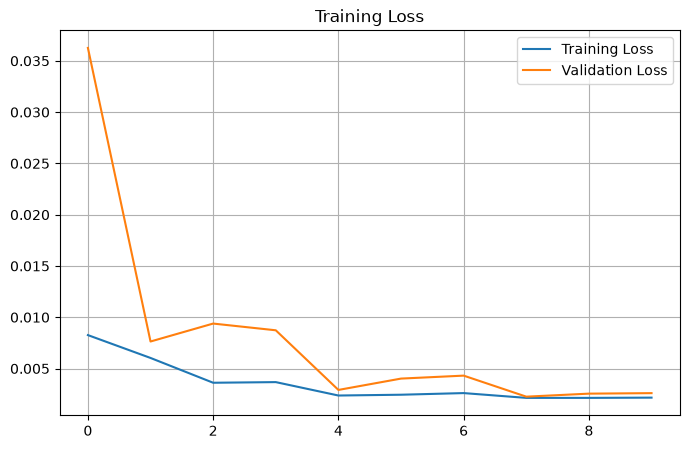

In [46]:
plt.figure(

    figsize=(8,5)

)

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.legend()

plt.grid()

plt.title("Training Loss")

plt.show()


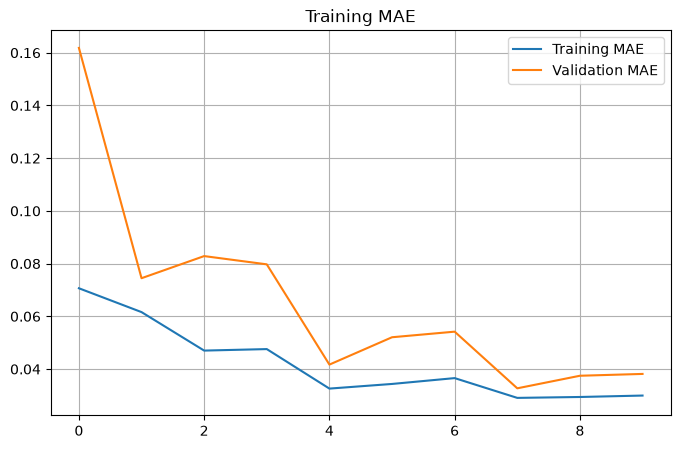

In [47]:
plt.figure(

    figsize=(8,5)

)

plt.plot(

    history.history["mae"],

    label="Training MAE"

)

plt.plot(

    history.history["val_mae"],

    label="Validation MAE"

)

plt.legend()

plt.grid()

plt.title("Training MAE")

plt.show()


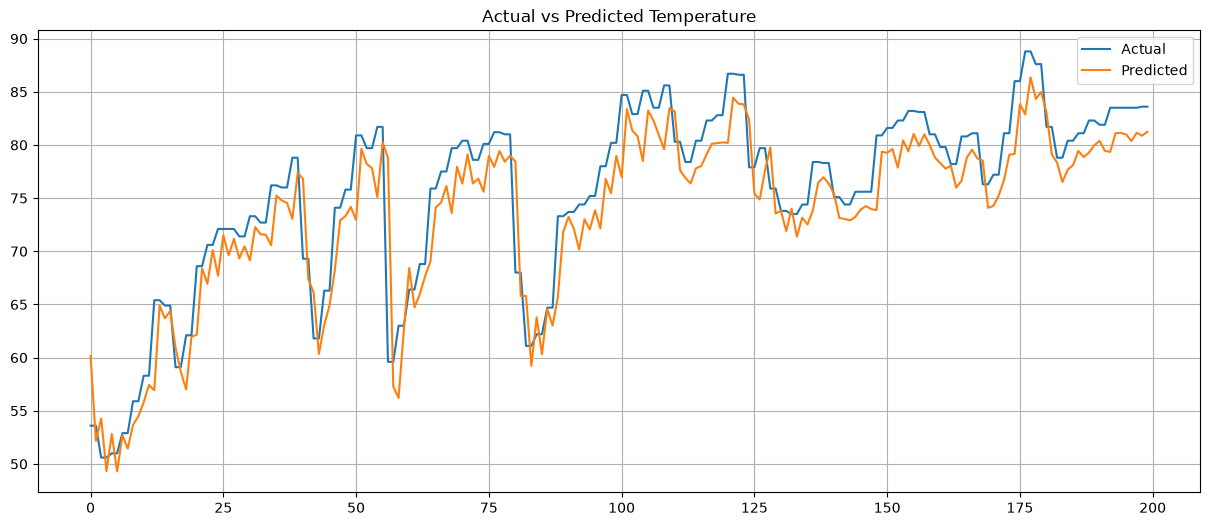

In [48]:
plt.figure(

    figsize=(15,6)

)

plt.plot(

    y_test_actual[:200],

    label="Actual"

)

plt.plot(

    predictions_actual[:200],

    label="Predicted"

)

plt.legend()

plt.grid()

plt.title("Actual vs Predicted Temperature")

plt.show()


In [49]:

prediction_df = pd.DataFrame({

    "Actual Temperature":

        y_test_actual.flatten(),

    "Predicted Temperature":

        predictions_actual.flatten()

})

print("\n")

print("="*70)

print("Prediction Results")

print("="*70)

display(

    prediction_df.head(20)

)




Prediction Results


,Actual Temperature,Predicted Temperature
0,53.600002,60.160664
1,53.600002,52.184410
2,50.600002,54.268204
3,50.600002,49.317600
4,51.000000,52.810329
5,51.000000,49.301258
6,52.900002,52.695858
7,52.900002,51.443859
8,55.900005,53.675472
9,55.900005,54.489555


In [50]:
print("\n")

print("="*70)

print("Business Insights")

print("="*70)

print("- RNN learns sequential dependencies in time-series data.")

print("- Previous temperatures help predict future temperatures.")

print("- Normalization improves convergence.")

print("- EarlyStopping prevents overfitting.")

print("- Simple RNN is suitable for learning fundamentals before LSTM.")




Business Insights
- RNN learns sequential dependencies in time-series data.
- Previous temperatures help predict future temperatures.
- Normalization improves convergence.
- EarlyStopping prevents overfitting.
- Simple RNN is suitable for learning fundamentals before LSTM.


In [51]:
print("\n")

print("="*70)

print("Simple RNN Summary")

print("="*70)

print("Dataset             : City Temperature")

print("Model               : Simple RNN")

print("Sequence Length     :", SEQUENCE_LENGTH)

print("RNN Units           : 32")

print("Batch Size          : 16")

print("Epochs              : 10")

print("Optimizer           : Adam")

print("Loss Function       : Mean Squared Error")

print("MAE                 :", round(mae_value,3))

print("RMSE                :", round(rmse_value,3))

print("="*70)

print("\n")

print("="*70)





Simple RNN Summary
Dataset             : City Temperature
Model               : Simple RNN
Sequence Length     : 20
RNN Units           : 32
Batch Size          : 16
Epochs              : 10
Optimizer           : Adam
Loss Function       : Mean Squared Error
MAE                 : 2.646
RMSE                : 3.845




In [52]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import load_model

from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error

In [53]:
loaded_model = load_model(

    "best_rnn_model.keras"

)

print("\n")

print("="*70)

print("Simple RNN Model Loaded Successfully")

print("="*70)




Simple RNN Model Loaded Successfully


In [54]:
predictions = loaded_model.predict(

    X_test,

    verbose=0

)


In [55]:
predictions_actual = scaler.inverse_transform(

    predictions

)

actual_values = scaler.inverse_transform(

    y_test.reshape(-1,1)

)


In [56]:
mae = mean_absolute_error(

    actual_values,

    predictions_actual

)

mse = mean_squared_error(

    actual_values,

    predictions_actual

)

rmse = np.sqrt(

    mse

)

print("\n")

print("="*70)

print("Evaluation Metrics")

print("="*70)

print("MAE  :", round(mae,3))

print("MSE  :", round(mse,3))

print("RMSE :", round(rmse,3))




Evaluation Metrics
MAE  : 2.646
MSE  : 14.787
RMSE : 3.845


In [57]:
last_sequence = X_test[-1]

last_sequence = np.expand_dims(

    last_sequence,

    axis=0

)

next_prediction = loaded_model.predict(

    last_sequence,

    verbose=0

)

next_temperature = scaler.inverse_transform(

    next_prediction

)

print("\n")

print("="*70)

print("Next Temperature Prediction")

print("="*70)

print(

    round(

        float(

            next_temperature[0][0]

        ),

        2

    )

)





Next Temperature Prediction
52.44


In [58]:
prediction_df = pd.DataFrame({

    "Actual Temperature":

        actual_values.flatten(),

    "Predicted Temperature":

        predictions_actual.flatten()

})

prediction_df.to_csv(

    "RNN_Predictions.csv",

    index=False

)

print("\n")

print("="*70)

print("Predictions Saved Successfully")

print("="*70)

display(

    prediction_df.head(

        20

    )

)




Predictions Saved Successfully


,Actual Temperature,Predicted Temperature
0,53.600002,60.160664
1,53.600002,52.184410
2,50.600002,54.268204
3,50.600002,49.317600
4,51.000000,52.810329
5,51.000000,49.301258
6,52.900002,52.695858
7,52.900002,51.443859
8,55.900005,53.675472
9,55.900005,54.489555


In [59]:

metrics_df = pd.DataFrame({

    "Metric":[

        "MAE",

        "MSE",

        "RMSE"

    ],

    "Value":[

        mae,

        mse,

        rmse

    ]

})

metrics_df.to_csv(

    "Evaluation_Metrics.csv",

    index=False

)

print("\n")

print("="*70)

print("Evaluation Metrics Saved")

print("="*70)

display(

    metrics_df

)




Evaluation Metrics Saved


,Metric,Value
0,MAE,2.645887
1,MSE,14.786526
2,RMSE,3.845325


In [60]:

history_df = pd.DataFrame(

    history.history

)

history_df.to_csv(

    "Training_History.csv",

    index=False

)

print("\n")

print("="*70)

print("Training History Saved")

print("="*70)




Training History Saved


In [61]:

history_df = pd.DataFrame(

    history.history

)

history_df.to_csv(

    "Training_History.csv",

    index=False

)

print("\n")

print("="*70)

print("Training History Saved")

print("="*70)




Training History Saved


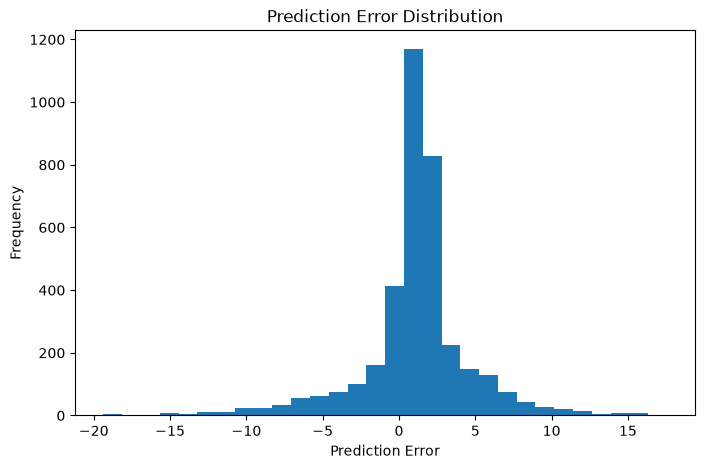

In [62]:
errors = actual_values.flatten() - predictions_actual.flatten()

plt.figure(

    figsize=(8,5)

)

plt.hist(

    errors,

    bins=30

)

plt.title(

    "Prediction Error Distribution"

)

plt.xlabel(

    "Prediction Error"

)

plt.ylabel(

    "Frequency"

)

plt.show()


In [63]:
deployment_summary = pd.DataFrame({

    "File":[

        "Simple RNN Model",

        "Prediction Results",

        "Evaluation Metrics",

        "Training History"

    ],

    "Saved As":[

        "best_rnn_model.keras",

        "RNN_Predictions.csv",

        "Evaluation_Metrics.csv",

        "Training_History.csv"

    ]

})

print("\n")

print("="*70)

print("Deployment Summary")

print("="*70)

display(

    deployment_summary

)




Deployment Summary


,File,Saved As
0,Simple RNN Model,best_rnn_model.keras
1,Prediction Results,RNN_Predictions.csv
2,Evaluation Metrics,Evaluation_Metrics.csv
3,Training History,Training_History.csv


In [64]:
print("\n")

print("="*70)

print("Business Insights")

print("="*70)

print("- Simple RNN captures short-term temporal patterns.")

print("- Previous temperature observations influence future predictions.")

print("- Normalization stabilizes training.")

print("- MAE provides average prediction error.")

print("- RMSE penalizes large forecasting errors.")

print("- Sequence models are widely used in weather forecasting, finance, and demand prediction.")




Business Insights
- Simple RNN captures short-term temporal patterns.
- Previous temperature observations influence future predictions.
- Normalization stabilizes training.
- MAE provides average prediction error.
- RMSE penalizes large forecasting errors.
- Sequence models are widely used in weather forecasting, finance, and demand prediction.


In [65]:
print("\n")

print("="*70)

print("Sequence Prediction using Simple RNN")

print("="*70)

print("Dataset                 : city_temperature.csv")

print("Problem Type            : Time Series Forecasting")

print("Model                   : Simple RNN")

print("Sequence Length         :", SEQUENCE_LENGTH)

print("RNN Units               : 32")

print("Batch Size              : 16")

print("Epochs                  : 10")

print("Optimizer               : Adam")

print("Loss Function           : Mean Squared Error")

print("MAE                     :", round(mae,3))

print("RMSE                    :", round(rmse,3))

print("Model Saved             : best_rnn_model.keras")

print("Prediction File         : RNN_Predictions.csv")

print("Metrics File            : Evaluation_Metrics.csv")

print("Training History File   : Training_History.csv")

print("Project Status          : Deployment Ready")

print("="*70)



Sequence Prediction using Simple RNN
Dataset                 : city_temperature.csv
Problem Type            : Time Series Forecasting
Model                   : Simple RNN
Sequence Length         : 20
RNN Units               : 32
Batch Size              : 16
Epochs                  : 10
Optimizer               : Adam
Loss Function           : Mean Squared Error
MAE                     : 2.646
RMSE                    : 3.845
Model Saved             : best_rnn_model.keras
Prediction File         : RNN_Predictions.csv
Metrics File            : Evaluation_Metrics.csv
Training History File   : Training_History.csv
Project Status          : Deployment Ready


In [66]:
print("\n")

print("="*70)

print("Sequence Prediction using Simple RNN")

print("Completed Successfully!")

print("="*70)



Sequence Prediction using Simple RNN
Completed Successfully!
